In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
# sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

# sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
# import yk22_mass_fluxes

import metpy

# import meteo


import pandas as pd
from IPython.display import display, HTML


## working local
drop_local_path = {
              "joanne4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/EUREC4A_JOANNE_Dropsonde-RD41_Level_4_v2.0.0.nc",
              "joanne3": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/EUREC4A_JOANNE_Dropsonde-RD41_Level_3_v2.0.0.nc",
              "beach4": "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/ORCESTRA_BEACH_level_4.nc",
              "beach3":  "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/dropsondes_34/ORCESTRA_BEACH_level_3.nc"
              }



## constants I always need
Lv = 2.5e6  # J/kg
cp = 1004.7 # J/kg K

Rd = 287.   # J / kg K

open dropsondes

In [34]:
## local access
beach4  = xr.open_dataset(drop_local_path["beach4"])  # level 4
beach3 = xr.open_dataset(drop_local_path["beach3"])  # level 3

In [35]:
beach4 = beach4.swap_dims({"sonde": "sonde_id"})
beach3 = beach3.swap_dims({"sonde": "sonde_id"})
common = np.intersect1d(beach3.sonde_id, beach4.sonde_id)

beach3 = beach3.sel(sonde_id=common)
beach4 = beach4.sel(sonde_id=common)

In [36]:
## local access
joanne4  = xr.open_dataset(drop_local_path["joanne4"])  # level 4
joanne3 = xr.open_dataset(drop_local_path["joanne3"])  # level 3


halo = joanne4.platform_id == "HALO"
joanne4 = joanne4.sel(alt=slice(0,7000)).where(halo, drop=True)

halo = joanne3.platform_id == "HALO"
joanne3 = joanne3.sel(alt=slice(0,7000)).where(halo, drop=True)

open radiosondes

In [37]:
radio_path_local = "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/radiosondes_3/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(radio_path_local)
ds_eureca = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)), drop=True)


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)), drop=True)


EUREC4A

In [45]:
ds_eureca = ds_eureca.swap_dims({"sounding": "launch_time"})
ds_eureca

<xarray.Dataset> Size: 50MB
Dimensions:      (launch_time: 182, alt: 3100, nv: 2)
Coordinates:
  * launch_time  (launch_time) datetime64[ns] 1kB 2020-01-16T20:53:46 ... 202...
    sounding     (launch_time) <U40 29kB 'BCO__ascent__13.16_-59.43__20200116...
  * alt          (alt) int16 6kB 0 10 20 30 40 ... 30950 30960 30970 30980 30990
    flight_time  (launch_time, alt) datetime64[ns] 5MB ...
    lat          (launch_time, alt) float32 2MB ...
    lon          (launch_time, alt) float32 2MB ...
Dimensions without coordinates: nv
Data variables: (12/19)
    p            (launch_time, alt) float32 2MB nan nan nan ... nan nan nan
    dz           (launch_time, alt) float32 2MB nan nan 0.0 ... nan nan nan
    ta           (launch_time, alt) float32 2MB nan nan nan ... nan nan nan
    dp           (launch_time, alt) float32 2MB nan nan 293.6 ... nan nan nan
    wspd         (launch_time, alt) float32 2MB nan nan 3.7 ... nan nan nan
    u            (launch_time, alt) float32 2MB nan nan -3.619 ... nan nan nan
    ...           ...
    rh           (launch_time, alt) float32 2MB nan nan nan ... nan nan nan
    N_ptu        (launch_time, alt) float32 2MB nan nan 1.0 2.0 ... nan nan nan
    N_gps        (launch_time, alt) float32 2MB nan nan 1.0 2.0 ... nan nan nan
    m_ptu        (launch_time, alt) float32 2MB 0.0 0.0 0.0 2.0 ... 0.0 0.0 0.0
    m_gps        (launch_time, alt) float32 2MB 0.0 0.0 2.0 2.0 ... 0.0 0.0 0.0
    ascent_flag  (launch_time) float32 728B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes: (12/13)
    title:            EUREC4A level 2 sounding data
    platform:         BCO
    instrument:       Radiosonde RS41-SGP by Vaisala
    doi:              10.25326/137
    created_with:     batch_interpolate_soundings.py with its last modificati...
    created_on:       Tue Dec 22 18:54:59 2020
    ...               ...
    Conventions:      CF-1.7
    campaign_id:      EUREC4A
    references:       Stephan et al. (2020): Ship- and island-based atmospher...
    acknowledgement:  The MPI-M is listed as the institute of first contact. ...
    instrument_id:    Vaisala-RS
    version:          v3.0.0

In [46]:
joanne3 = joanne3.swap_dims({"sonde_id": "launch_time"})
joanne3

<xarray.Dataset> Size: 57MB
Dimensions:            (launch_time: 810, alt: 701, nv: 2)
Coordinates:
  * launch_time        (launch_time) datetime64[ns] 6kB 2020-01-19T16:55:14 ....
    sonde_id           (launch_time) <U13 42kB 'HALO-0119_s02' ... 'HALO-0218...
  * alt                (alt) int16 1kB 0 10 20 30 40 ... 6970 6980 6990 7000
    interpolated_time  (launch_time, alt) datetime64[ns] 5MB ...
    lat                (launch_time, alt) float32 2MB ...
    lon                (launch_time, alt) float32 2MB ...
Dimensions without coordinates: nv
Data variables: (12/23)
    p                  (launch_time, alt) float32 2MB nan ... 4.313e+04
    ta                 (launch_time, alt) float32 2MB nan 299.0 ... 257.5 257.5
    rh                 (launch_time, alt) float32 2MB nan 0.7669 ... 0.1154
    wspd               (launch_time, alt) float32 2MB nan 9.681 ... 5.539 5.482
    wdir               (launch_time, alt) float32 2MB nan 67.17 ... 357.1 356.0
    u                  (launch_time, alt) float32 2MB nan -8.922 ... 0.3828
    ...                 ...
    N_gps              (launch_time, alt) float32 2MB nan 2.0 2.0 ... nan 1.0
    m_p                (launch_time, alt) float32 2MB nan 2.0 2.0 ... nan 1.0
    m_ta               (launch_time, alt) float32 2MB nan 2.0 2.0 ... nan 1.0
    m_rh               (launch_time, alt) float32 2MB nan 2.0 2.0 ... nan 1.0
    m_gps              (launch_time, alt) float32 2MB nan 2.0 2.0 ... nan 1.0
    alt_bnds           (alt, nv, launch_time) float64 9MB -5.0 ... 7.005e+03
Attributes: (12/16)
    title:                   EUREC4A JOANNE Level-3
    doi:                     10.25326/246
    created with:            run_joanne.py doi:10.5281/zenodo.5521192
    Conventions:             CF-1.8
    campaign_id:             EUREC4A
    project_id:              JOANNE
    ...                      ...
    JOANNE_version:          2.0.0
    author:                  Geet George
    author_email:            geet.george@mpimet.mpg.de
    featureType:             trajectory
    reference:               George et al., JOANNE : Joint dropsonde Observat...
    creation_time:           2021-09-22 14:35:24.817595 UTC

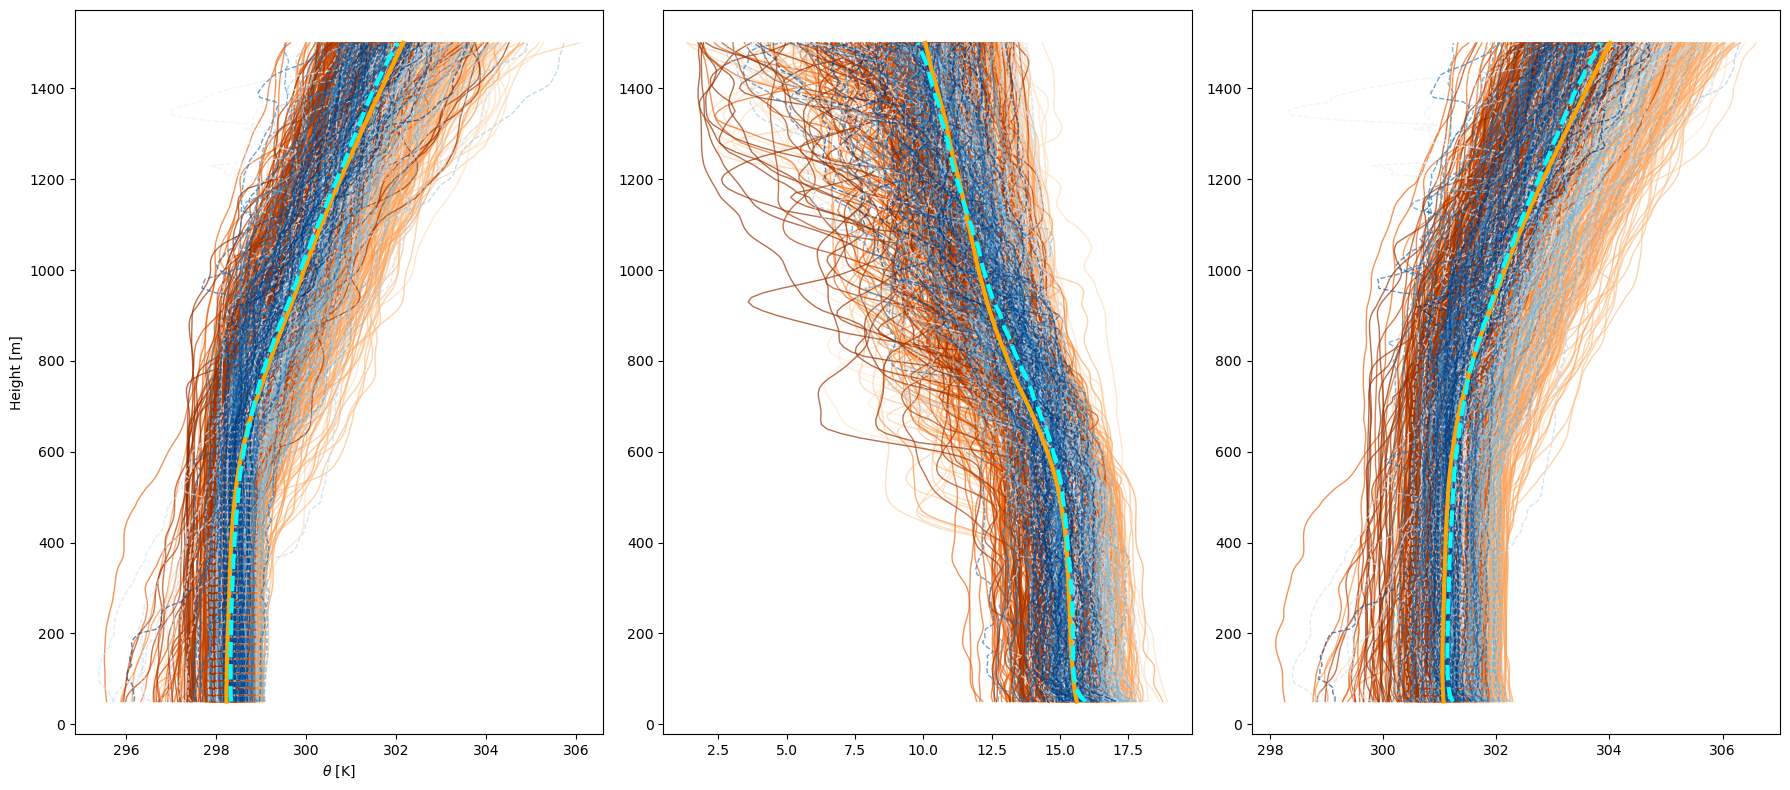

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))
cmaps = [plt.cm.Oranges, plt.cm.Blues]
cols  = ["orange", "cyan"]
linestyle = ["-", "dashed"]

for j, ds in enumerate([joanne3, ds_eureca]):
    theta = ds.theta.sel(alt=slice(50, 1500))
    q = ds.q.sel(alt=slice(50, 1500))
    theta_v = theta*(1 + 0.61*q)

    # Convert launch_time to datetime if necessary
    times = theta.launch_time.values

    # Map launch times to [0, 1] for the colormap
    tnum = mdates.date2num(times)
    norm = plt.Normalize(tnum.min(), tnum.max())
    cmap = cmaps[j]

    for i, t in enumerate(times):
        ax[0].plot(
            theta.isel(launch_time=i),
            theta.alt,
            color=cmap(norm(mdates.date2num(t))),
            alpha=0.7,
            lw=1,
            linestyle=linestyle[j]
        )
        ax[1].plot(
                    1e3*q.isel(launch_time=i),
                    q.alt,
                    color=cmap(norm(mdates.date2num(t))),
                    alpha=0.7,
                    lw=1,
                    linestyle=linestyle[j]
        )

        ax[2].plot(
                    theta_v.isel(launch_time=i),
                    theta_v.alt,
                    color=cmap(norm(mdates.date2num(t))),
                    alpha=0.7,
                    lw=1,
                    linestyle=linestyle[j]
        )
        
    # Colorbar for this dataset
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax)
    # cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    # cbar.set_label("Launch time")



for j, ds in enumerate([joanne3, ds_eureca]):
    theta = ds.theta.sel(alt=slice(50, 1500))
    q = ds.q.sel(alt=slice(50, 1500))
    theta_v = theta*(1 + 0.61*q)
    ax[0].plot(
                    theta.mean(dim="launch_time"),
                    theta.alt,
                    color=cols[j],
                    alpha=1.,
                    lw=3,
                    linestyle=linestyle[j]
        )
    ax[1].plot(
                1e3*q.mean(dim="launch_time"),
                q.alt,
                color=cols[j],
                alpha=1.,
                lw=3,
                linestyle=linestyle[j]
    )

    ax[2].plot(
                theta_v.mean(dim="launch_time"),
                theta_v.alt,
                color=cols[j],
                alpha=1.,
                lw=3,
                linestyle=linestyle[j]
    )















ax[0].set_xlabel(r"$\theta$ [K]")
ax[0].set_ylabel("Height [m]")
plt.tight_layout()
plt.show()

ORCESTRA

In [38]:
ds_orcestra = ds_orcestra.rename({"height":"alt"})
ds_orcestra

<xarray.Dataset> Size: 28MB
Dimensions:            (launch_time: 141, alt: 3100)
Coordinates:
  * launch_time        (launch_time) datetime64[ns] 1kB 2024-09-07T01:05:09.9...
  * alt                (alt) float32 12kB 0.0 10.0 20.0 ... 3.098e+04 3.099e+04
    interpolated_time  (launch_time, alt) datetime64[ns] 3MB ...
    lat                (launch_time, alt) float32 2MB ...
    lon                (launch_time, alt) float32 2MB ...
Data variables: (12/18)
    ascent_flag        (launch_time) float32 564B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dp                 (launch_time, alt) float32 2MB nan nan nan ... nan nan
    dz                 (launch_time, alt) float32 2MB nan nan nan ... nan nan
    iwv                (launch_time) float32 564B 55.54 53.01 ... 45.83 51.64
    launch_lat         (launch_time) float32 564B 13.16 13.16 ... 13.16 13.16
    launch_lon         (launch_time) float32 564B -59.43 -59.43 ... -59.43
    ...                 ...
    ta                 (launch_time, alt) float32 2MB nan nan nan ... nan nan
    theta              (launch_time, alt) float32 2MB nan nan nan ... nan nan
    u                  (launch_time, alt) float32 2MB nan nan nan ... nan nan
    v                  (launch_time, alt) float32 2MB nan nan nan ... nan nan
    wdir               (launch_time, alt) float32 2MB nan nan nan ... nan nan
    wspd               (launch_time, alt) float32 2MB nan nan nan ... nan nan
Attributes:
    creator_email:  marius.winkler@mpimet.mpg.de, marius.rixen@mpimet.mpg.de
    creator_name:   Marius Winkler, Marius Rixen
    featureType:    profile
    history:        Meteomodem Eoscan Software (2.1.241218); Vaisala Sounding...
    keywords:       ORCESTRA, RAPSODI, Radiosonde Profiles, Sounding, INMG, R...
    license:        CC-BY-4.0
    platform:       INMG, RV Meteor, BCO
    project:        ORCESTRA, PERCUSION, BOW-TIE, PICCOLO, SCORE, MAESTRO
    references:     https://github.com/observingClouds/pysonde
    source:         Radiosondes
    summary:        Vertical atmospheric profile, retrieved from atmospheric ...
    title:          RAPSODI Radiosonde Measurements during ORCESTRA (Level 2)

In [39]:
beach3 = beach3.swap_dims({"sonde_id":"launch_time"}).rename({"altitude":"alt"})
beach3

<xarray.Dataset> Size: 81MB
Dimensions:            (launch_time: 1058, alt: 1460)
Coordinates:
  * launch_time        (launch_time) datetime64[ns] 8kB 2024-08-18T11:49:03 ....
    sonde_id           (launch_time) <U8 34kB '000f256c' ... 'ffdd9f57'
    launch_altitude    (launch_time) float32 4kB ...
    launch_lat         (launch_time) float32 4kB ...
    launch_lon         (launch_time) float32 4kB ...
  * alt                (alt) float64 12kB 0.0 10.0 20.0 ... 1.458e+04 1.459e+04
Data variables: (12/22)
    flight_id          (launch_time) <U14 59kB ...
    interpolated_time  (launch_time, alt) datetime64[ns] 12MB ...
    iwv                (launch_time) float32 4kB ...
    lat                (launch_time, alt) float32 6MB ...
    lon                (launch_time, alt) float32 6MB ...
    p                  (launch_time, alt) float32 6MB ...
    ...                 ...
    u_qc               (launch_time) int8 1kB ...
    v                  (launch_time, alt) float32 6MB ...
    v_qc               (launch_time) int8 1kB ...
    vaisala_serial_id  (launch_time) <U9 38kB ...
    wdir               (launch_time, alt) float32 6MB ...
    wspd               (launch_time, alt) float32 6MB ...
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 3)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 3 BEACH dataset. It contains...
    processing_level:  3
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

In [41]:
west = beach3.launch_lon < -40.
beach3_w = beach3.where(west, drop=True)

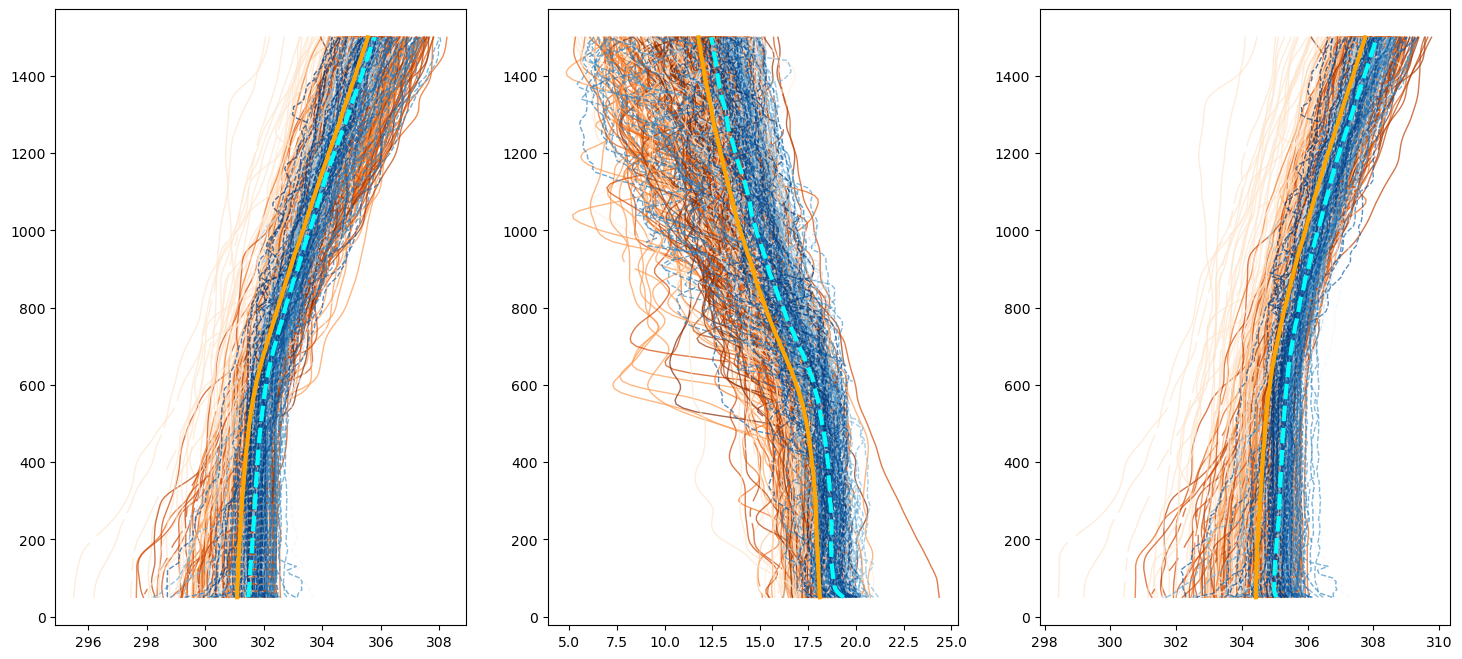

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))
cmaps = [plt.cm.Oranges, plt.cm.Blues]
cols  = ["orange", "cyan"]
linestyle = ["-", "dashed"]

for j, ds in enumerate([beach3_w, ds_orcestra]):
    theta = ds.theta.sel(alt=slice(50, 1500))
    q = ds.q.sel(alt=slice(50, 1500))
    theta_v = theta*(1 + 0.61*q)

    # Convert launch_time to datetime if necessary
    times = theta.launch_time.values

    # Map launch times to [0, 1] for the colormap
    tnum = mdates.date2num(times)
    norm = plt.Normalize(tnum.min(), tnum.max())
    cmap = cmaps[j]

    for i, t in enumerate(times):
        ax[0].plot(
            theta.isel(launch_time=i),
            theta.alt,
            color=cmap(norm(mdates.date2num(t))),
            alpha=0.7,
            lw=1,
            linestyle=linestyle[j]
        )
        ax[1].plot(
                    1e3*q.isel(launch_time=i),
                    q.alt,
                    color=cmap(norm(mdates.date2num(t))),
                    alpha=0.7,
                    lw=1,
                    linestyle=linestyle[j]
        )

        ax[2].plot(
                    theta_v.isel(launch_time=i),
                    theta_v.alt,
                    color=cmap(norm(mdates.date2num(t))),
                    alpha=0.7,
                    lw=1,
                    linestyle=linestyle[j]
        )
        
    # Colorbar for this dataset
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax)
    # cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    # cbar.set_label("Launch time")



for j, ds in enumerate([beach3_w, ds_orcestra]):
    theta = ds.theta.sel(alt=slice(50, 1500))
    q = ds.q.sel(alt=slice(50, 1500))
    theta_v = theta*(1 + 0.61*q)
    ax[0].plot(
                    theta.mean(dim="launch_time"),
                    theta.alt,
                    color=cols[j],
                    alpha=1.,
                    lw=3,
                    linestyle=linestyle[j]
        )
    ax[1].plot(
                1e3*q.mean(dim="launch_time"),
                q.alt,
                color=cols[j],
                alpha=1.,
                lw=3,
                linestyle=linestyle[j]
    )

    ax[2].plot(
                theta_v.mean(dim="launch_time"),
                theta_v.alt,
                color=cols[j],
                alpha=1.,
                lw=3,
                linestyle=linestyle[j]
    )

